# Phase 5 — Pipeline Walkthrough (Portfolio Notebook)

> Goal: demonstrate the MARS recommendation pipeline end-to-end (Stage 0 → Stage 1 → Stage 2 → post-processing) with interpretable diagnostics and lightweight visualizations.

**Design constraints**
- Runs from any working directory (resolves project root)
- Avoids Streamlit dependencies (pure Python)
- Keeps runtime low by sampling where appropriate

Seed showcased: **Steins;Gate** (best-effort resolution; falls back if not found).

In [2]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_colwidth', 200)


def find_project_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'src').exists() and (p / 'data').exists() and ((p / 'requirements.txt').exists() or (p / '.git').exists()):
            return p
    return start


ROOT = find_project_root(Path.cwd())
print(f'Project root: {ROOT}')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / 'data' / 'processed'
MODELS_DIR = ROOT / 'models'
REPORTS_DIR = ROOT / 'reports'

DATA_DIR, MODELS_DIR, REPORTS_DIR

Project root: c:\Users\dedwa\OneDrive\Desktop\Dromund_Kass\MARS\MyAnimeRecommendationSystem


(WindowsPath('c:/Users/dedwa/OneDrive/Desktop/Dromund_Kass/MARS/MyAnimeRecommendationSystem/data/processed'),
 WindowsPath('c:/Users/dedwa/OneDrive/Desktop/Dromund_Kass/MARS/MyAnimeRecommendationSystem/models'),
 WindowsPath('c:/Users/dedwa/OneDrive/Desktop/Dromund_Kass/MARS/MyAnimeRecommendationSystem/reports'))

## 1) Setup & Data Overview

We load the same artifact bundle the app uses via `build_artifacts()`, then inspect:
- Metadata shape and a compact schema view
- Model files present (rough footprint)
- MAL score histogram (if present)

In [3]:
from src.app.artifacts_loader import build_artifacts

t0 = time.perf_counter()
bundle = build_artifacts(data_dir=DATA_DIR, models_dir=MODELS_DIR, reports_dir=REPORTS_DIR)
print(f'Loaded artifacts in {(time.perf_counter() - t0) * 1000:.0f}ms')

sorted(bundle.keys()), sorted(bundle.get('models', {}).keys())[:25]

Loaded artifacts in 17022ms


(['diversity', 'explanations', 'metadata', 'models'],
 ['_knn_stem',
  '_mf_stem',
  '_synopsis_embeddings_stem',
  '_synopsis_neural_embeddings_stem',
  '_synopsis_tfidf_stem',
  'item_knn_sklearn_v1.0',
  'item_knn_sklearn_v2025.11.21_202756',
  'knn',
  'mf',
  'mf_mean_user_scores',
  'mf_mean_user_vector',
  'mf_sgd_v1.0',
  'mf_sgd_v2025.11.21_202756',
  'synopsis_embeddings',
  'synopsis_embeddings_v2025.12.31_161712',
  'synopsis_neural_embeddings',
  'synopsis_neural_embeddings_v2026.01.31_235728',
  'synopsis_tfidf',
  'synopsis_tfidf_v2025.12.30_195311'])

In [4]:
metadata: pd.DataFrame = bundle['metadata']
print('metadata shape:', metadata.shape)

schema = pd.DataFrame(
    {
        'column': metadata.columns,
        'dtype': [str(dt) for dt in metadata.dtypes],
        'non_null': [int(metadata[c].notna().sum()) for c in metadata.columns],
    }
)

display(schema.head(30))

metadata shape: (13037, 20)


,column,dtype,non_null
0,anime_id,int64,13037
1,title_display,object,13037
2,title_english,object,6655
3,title_primary,object,12923
4,title,object,0
5,title_japanese,object,12903
6,genres,object,13037
7,themes,object,13037
8,demographics,object,13037
9,synopsis,object,12635


,file,size_mb
0,item_knn_sklearn_v1.0.joblib,180.526065
1,item_knn_sklearn_v2025.11.21_202756.joblib,180.526065
2,mf_sgd_v1.0.joblib,23.136600
3,mf_sgd_v2025.11.21_202756.joblib,22.813388
4,synopsis_embeddings_v2025.12.31_161712.joblib,11.461355
5,synopsis_neural_embeddings_v2026.01.31_235728.joblib,17.120366
6,synopsis_tfidf_v2025.12.30_195311.joblib,4.885398


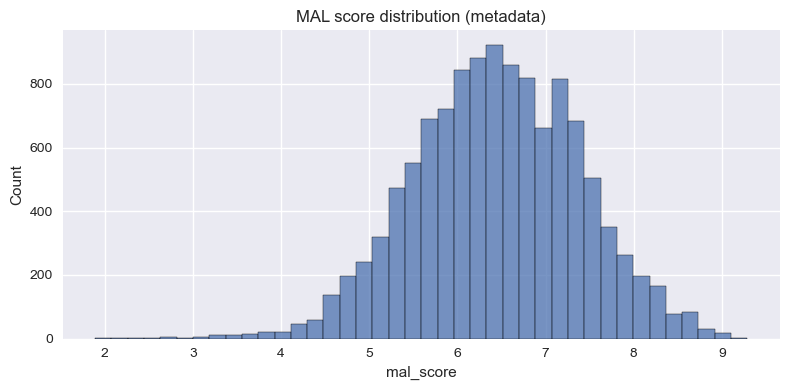

In [5]:
# Model footprint (approx)
model_files = []
if MODELS_DIR.exists():
    for p in sorted(MODELS_DIR.glob('*.joblib')):
        model_files.append({'file': p.name, 'size_mb': p.stat().st_size / (1024 * 1024)})

model_df = pd.DataFrame(model_files)
display(model_df)

if 'mal_score' in metadata.columns:
    s = pd.to_numeric(metadata['mal_score'], errors='coerce').dropna()
    plt.figure(figsize=(8, 4))
    sns.histplot(s, bins=40)
    plt.title('MAL score distribution (metadata)')
    plt.xlabel('mal_score')
    plt.tight_layout()
    plt.show()
else:
    print('metadata has no mal_score column')

## 2) Choose a Seed

The plan calls out **Steins;Gate** (`anime_id = 9253`). IDs can vary across datasets, so we resolve the seed robustly:
- Try exact `anime_id` first
- Else search by title (case-insensitive contains)

We store a single seed ID/title to feed into Stage 0.

In [6]:
SEED_TARGET_ID = 9253
SEED_QUERY = 'steins;gate'

metadata_by_id = metadata.set_index('anime_id', drop=False)


def _best_title(row: pd.Series) -> str:
    for c in ['title_display', 'title_primary', 'title', 'title_english']:
        if c in row.index:
            v = row.get(c)
            if isinstance(v, str) and v.strip():
                return v
    return str(int(row.get('anime_id')))


seed_id = None
seed_title = None

if SEED_TARGET_ID in metadata_by_id.index:
    row = metadata_by_id.loc[SEED_TARGET_ID]
    seed_id = int(row['anime_id'])
    seed_title = _best_title(row)
else:
    title_cols = [c for c in ['title_display', 'title', 'title_primary', 'title_english'] if c in metadata.columns]
    if not title_cols:
        row = metadata.iloc[0]
    else:
        haystack = pd.Series([''] * len(metadata))
        for c in title_cols:
            haystack = haystack.fillna('') + ' ' + metadata[c].fillna('')
        hits = metadata.loc[haystack.str.lower().str.contains(SEED_QUERY)].copy()
        if len(hits) == 0:
            row = metadata.iloc[0]
        else:
            if 'mal_score' in hits.columns:
                hits['mal_score'] = pd.to_numeric(hits['mal_score'], errors='coerce')
                hits = hits.sort_values('mal_score', ascending=False)
            row = hits.iloc[0]
    seed_id = int(row['anime_id'])
    seed_title = _best_title(row)

seed_id, seed_title

(9253, 'Steins;Gate')

## 3) Build App-Like Inference Objects

The Streamlit app builds a `HybridRecommender` from the MF artifact by computing demo-user MF scores and (optionally) a popularity prior from the kNN artifact.

We replicate that here so we can run `run_seed_based_pipeline()` exactly like the app.

In [7]:
from src.app.diversity import compute_popularity_percentiles
from src.app.recommender import HybridComponents, HybridRecommender


def build_app_like_engine(bundle: dict):
    mf_model = bundle.get('models', {}).get('mf')
    if mf_model is None:
        raise RuntimeError("MF model alias 'mf' not found in bundle['models']")

    index_to_item = mf_model.index_to_item
    n_items = len(index_to_item)
    item_ids = np.asarray([int(index_to_item[i]) for i in range(n_items)], dtype=np.int64)

    demo_user_index = 0
    demo_scores = float(mf_model.global_mean) + (mf_model.P[demo_user_index] @ mf_model.Q.T)
    mf_scores = np.asarray(demo_scores, dtype=np.float32).reshape(1, -1)

    components = HybridComponents(mf=mf_scores, knn=None, pop=None, item_ids=item_ids)

    pop_pct_by_anime_id = {}
    knn_model = bundle.get('models', {}).get('knn')
    try:
        if (
            knn_model is not None
            and hasattr(knn_model, 'item_pop')
            and hasattr(knn_model, 'item_to_index')
            and knn_model.item_pop is not None
            and knn_model.item_to_index is not None
        ):
            it2i = knn_model.item_to_index
            pop_arr = np.asarray(knn_model.item_pop, dtype=np.float32)

            pop_pct_arr = compute_popularity_percentiles(pop_arr)
            pop_pct_by_anime_id = {
                int(aid): float(pop_pct_arr[int(idx)])
                for aid, idx in it2i.items()
                if idx is not None and 0 <= int(idx) < len(pop_pct_arr)
            }

            pop_vec = np.zeros(len(item_ids), dtype=np.float32)
            for j, aid in enumerate(item_ids):
                idx = it2i.get(int(aid))
                if idx is not None and 0 <= int(idx) < len(pop_arr):
                    pop_vec[j] = float(pop_arr[int(idx)])
            components.pop = pop_vec
    except Exception:
        pop_pct_by_anime_id = {}

    recommender = HybridRecommender(components)

    def pop_pct_fn(anime_id: int) -> float:
        try:
            return float(pop_pct_by_anime_id.get(int(anime_id), 0.5))
        except Exception:
            return 0.5

    return components, recommender, pop_pct_fn


components, recommender, pop_pct_fn = build_app_like_engine(bundle)
type(recommender), type(components)

(src.app.recommender.HybridRecommender, src.app.recommender.HybridComponents)

## 4) Stage 0 — Candidate Generation

Stage 0 narrows the universe into a focused candidate pool using three tiers:
1) **Neural semantic neighbors** (primary)
2) **Strict metadata overlap** (confirmer)
3) **Popularity backfill** (safety)

We run the production Stage 0 builder and visualize tier counts + overlaps.

In [8]:
from src.app.constants import (
    STAGE0_META_MIN_GENRE_OVERLAP,
    STAGE0_META_MIN_THEME_OVERLAP,
    STAGE0_NEURAL_TOPK,
    STAGE0_POOL_CAP,
    STAGE0_POPULARITY_BACKFILL,
)
from src.app.stage0_candidates import build_stage0_seed_candidate_pool
from src.app.synopsis_neural_embeddings import SYNOPSIS_NEURAL_MIN_SIM
from src.app.synopsis_neural_embeddings import compute_seed_similarity_map as compute_seed_neural_similarity_map

synopsis_neural = bundle.get('models', {}).get('synopsis_neural_embeddings')

stage0_ids, stage0_flags_by_id, stage0_diag = build_stage0_seed_candidate_pool(
    metadata=metadata,
    seed_ids=[seed_id],
    ranked_hygiene_exclude_ids=set(),
    watched_ids=set(),
    neural_artifact=synopsis_neural,
    neural_topk=int(STAGE0_NEURAL_TOPK),
    meta_min_genre_overlap=float(STAGE0_META_MIN_GENRE_OVERLAP),
    meta_min_theme_overlap=float(STAGE0_META_MIN_THEME_OVERLAP),
    popularity_backfill=int(STAGE0_POPULARITY_BACKFILL),
    pool_cap=int(STAGE0_POOL_CAP),
    pop_item_ids=(components.item_ids if components is not None else None),
    pop_scores=(components.pop if components is not None else None),
)

stage0_diag

Stage0Diagnostics(stage0_pool_raw=2277, stage0_from_neural_raw=1500, stage0_from_meta_strict_raw=830, stage0_from_popularity_raw=100, stage0_after_hygiene=2276, stage0_after_cap=2276, stage0_from_neural=1500, stage0_from_meta_strict=829, stage0_from_popularity=99, stage0_neural_only=1368, stage0_meta_only=695, stage0_pop_only=64, stage0_neural_and_meta=117)

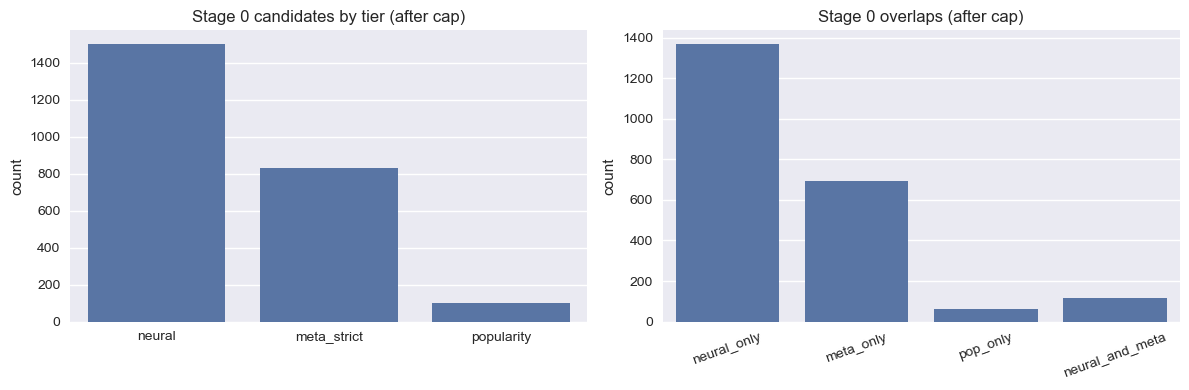

2276

In [9]:
counts = {
    'neural': int(stage0_diag.stage0_from_neural),
    'meta_strict': int(stage0_diag.stage0_from_meta_strict),
    'popularity': int(stage0_diag.stage0_from_popularity),
}
overlaps = {
    'neural_only': int(stage0_diag.stage0_neural_only),
    'meta_only': int(stage0_diag.stage0_meta_only),
    'pop_only': int(stage0_diag.stage0_pop_only),
    'neural_and_meta': int(stage0_diag.stage0_neural_and_meta),
}

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), ax=ax[0])
ax[0].set_title('Stage 0 candidates by tier (after cap)')
ax[0].set_ylabel('count')

sns.barplot(x=list(overlaps.keys()), y=list(overlaps.values()), ax=ax[1])
ax[1].set_title('Stage 0 overlaps (after cap)')
ax[1].set_ylabel('count')
ax[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

len(stage0_ids)

In [10]:
if synopsis_neural is None:
    print('No synopsis_neural_embeddings artifact; skipping neighbors table.')
else:
    sims = compute_seed_neural_similarity_map(
        synopsis_neural, seed_ids=[seed_id], min_sim=float(SYNOPSIS_NEURAL_MIN_SIM)
    )
    top = sorted(
        ((int(aid), float(sim)) for aid, sim in sims.items() if int(aid) != int(seed_id)),
        key=lambda x: x[1],
        reverse=True,
    )[:20]
    nn = pd.DataFrame(top, columns=['anime_id', 'cosine_sim'])
    cols = [c for c in ['anime_id', 'title_display', 'genres', 'type', 'mal_score'] if c in metadata.columns]
    nn = nn.merge(metadata[cols], on='anime_id', how='left')
    display(nn)

,anime_id,cosine_sim,title_display,genres,type,mal_score
0,30484,0.683089,Steins;Gate 0,"[Drama, Sci-Fi, Suspense]",TV,8.55
1,32188,0.612453,Steins;Gate: Open the Missing Link - Divide By Zero,"[Sci-Fi, Suspense]",TV Special,8.26
2,27957,0.563647,Steins;Gate: The Sagacious Wisdom of Cognitive Computing,"[Comedy, Sci-Fi]",ONA,7.44
3,10863,0.458602,Steins;Gate: Egoistic Poriomania,"[Comedy, Sci-Fi]",Special,8.29
4,4086,0.452945,Mukamuka Paradise,"[Adventure, Comedy]",TV,6.90
5,20125,0.438042,Tobidase! Machine Hiryuu,[Comedy],TV,5.81
6,48549,0.434841,Dr. Stone: New World,"[Adventure, Comedy, Sci-Fi]",None,8.15
7,546,0.429267,Wind: A Breath of Heart (TV),"[Drama, Romance, Supernatural]",TV,5.92
8,11577,0.423062,Steins;Gate: The Movie - Load Region of Déjà Vu,"[Drama, Sci-Fi]",Movie,8.45
9,12401,0.422146,The Chohjotai,[Action],OVA,5.51


## 5) Stage 1 — Shortlist Construction

Stage 1 filters the Stage 0 pool into a shortlist using semantic admission and type/episode gates.

We run the full seed-based pipeline once and inspect Stage 0/1 diagnostics.

In [11]:
from src.app.constants import BALANCED_WEIGHTS
from src.app.scoring_pipeline import ScoringContext, run_seed_based_pipeline

ctx = ScoringContext(
    metadata=metadata,
    bundle=bundle,
    recommender=recommender,
    components=components,
    seed_ids=[seed_id],
    seed_titles=[seed_title],
    user_index=0,
    weights=BALANCED_WEIGHTS,
    n_requested=10,
    pop_pct_fn=pop_pct_fn,
)

result = run_seed_based_pipeline(ctx)
result.active_scoring_path, len(result.ranked_items), result.timing

('Seed-based',
 10,
 {'prep': 0.03200000000651926,
  'stage0': 0.5780000000086147,
  'stage1': 0.7179999999934807,
  'stage2': 0.10999999998603016,
  'total': 1.437999999994645})

In [12]:
display(pd.DataFrame([result.stage0_diagnostics]))
display(pd.DataFrame([result.stage1_diagnostics]))

if result.stage0_enforcement:
    display(pd.DataFrame([result.stage0_enforcement]))
if result.franchise_cap_diagnostics:
    display(pd.DataFrame([result.franchise_cap_diagnostics]))
if result.diversity_stats:
    display(pd.DataFrame([result.diversity_stats]))

,stage0_pool_raw,stage0_raw_counts_by_tier,stage0_after_hygiene,stage0_after_cap,stage0_after_cap_counts_by_tier,stage0_overlap_counts
0,2277,"{'stage0_from_neural': 1500, 'stage0_from_meta_strict': 830, 'stage0_from_popularity': 100}",2276,2276,"{'stage0_from_neural': 1500, 'stage0_from_meta_strict': 829, 'stage0_from_popularity': 99}","{'stage0_neural_only': 1368, 'stage0_meta_only': 695, 'stage0_pop_only': 64, 'stage0_neural_and_meta': 117}"


,stage1_iterated_candidate_count,shortlist_size,semantic_conf_tier,semantic_conf_score,pool_a_size,pool_b_size,k_sem,k_meta
0,2276,600,none,0.0,56,1156,0,600


,stage0_after_hygiene_size,stage1_iterated_candidate_count,shortlist_size,final_scored_candidate_count,top20_in_stage0_count,top50_in_stage0_count
0,2276,2276,600,583,10,10


## 6) Stage 2 — Hybrid Scoring (Readable Breakdown)

Stage 2 applies the hybrid scoring formula. Each recommendation item includes:
- `score`: final ranking score
- `explanation`: compact human-readable explanation
- `_raw_components`: raw internal signals used to build the score

Below we render the top-N table, plot score distribution, and visualize raw components for the top-5.

,rank,anime_id,title_display,score,type,genres
0,1,32188,Steins;Gate: Open the Missing Link - Divide By Zero,2.977356,TV Special,"[Sci-Fi, Suspense]"
1,2,30484,Steins;Gate 0,2.930731,TV,"[Drama, Sci-Fi, Suspense]"
2,3,27957,Steins;Gate: The Sagacious Wisdom of Cognitive Computing,2.451917,ONA,"[Comedy, Sci-Fi]"
3,4,339,Serial Experiments Lain,1.921313,TV,"[Avant Garde, Award Winning, Drama, Mystery, Sci-Fi, Supernatural, Suspense]"
4,5,329,Planetes,1.909734,TV,"[Award Winning, Drama, Romance, Sci-Fi]"
5,6,18195,Little Busters! ~Refrain~,1.862852,TV,"[Comedy, Drama, Romance]"
6,7,2164,Den-noh Coil,1.856780,TV,"[Adventure, Award Winning, Drama, Mystery, Sci-Fi]"
7,8,19,Monster,1.817428,TV,"[Drama, Mystery, Suspense]"
8,9,16,Honey and Clover,1.785290,TV,"[Comedy, Drama, Romance]"
9,10,2747,Astro Boy,1.773233,TV,"[Action, Adventure, Drama, Sci-Fi]"


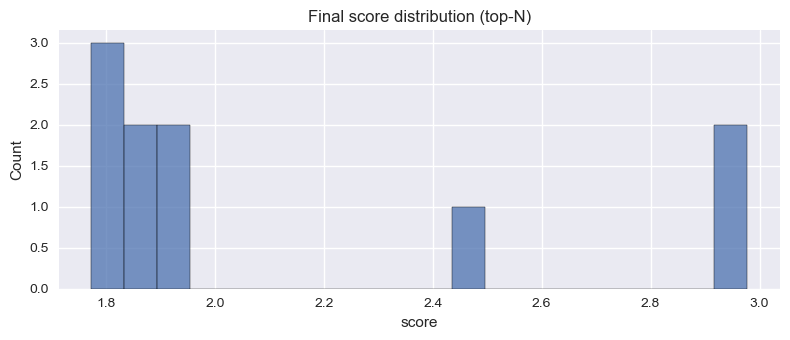

In [13]:
ranked = pd.DataFrame(result.ranked_items)

if ranked.empty:
    print('No ranked items returned.')
else:
    ranked['rank'] = np.arange(1, len(ranked) + 1)
    ranked['anime_id'] = ranked['anime_id'].astype(int)

    cols = [c for c in ['anime_id', 'title_display', 'genres', 'type', 'mal_score'] if c in metadata.columns]
    meta_small = metadata[cols].copy() if cols else metadata[['anime_id']].copy()
    joined = ranked.merge(meta_small, on='anime_id', how='left')

    display(joined[['rank', 'anime_id', 'title_display', 'score', 'type', 'genres']].head(10))

    plt.figure(figsize=(8, 3.5))
    sns.histplot(joined['score'], bins=20)
    plt.title('Final score distribution (top-N)')
    plt.xlabel('score')
    plt.tight_layout()
    plt.show()

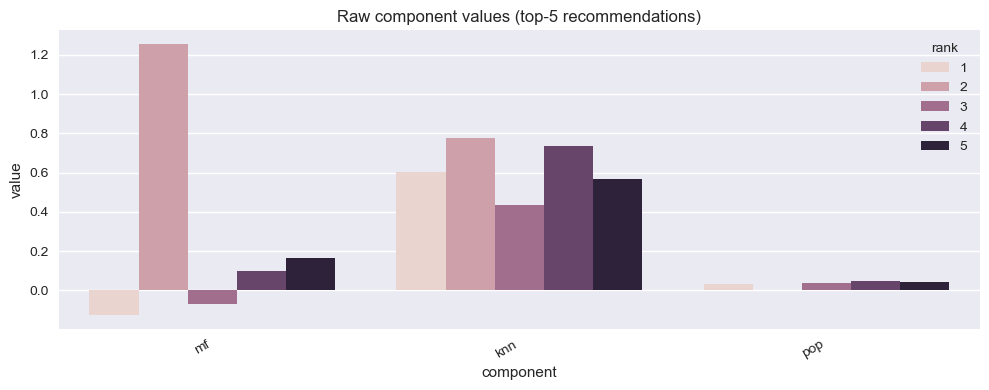

,rank,component,value
1,1,knn,0.602679
2,1,pop,0.032555
0,1,mf,-0.126462
3,2,mf,1.255014
4,2,knn,0.776109
5,2,pop,0.000113
7,3,knn,0.432570
8,3,pop,0.036565
6,3,mf,-0.070048
10,4,knn,0.734912


In [14]:
if ranked.empty:
    pass
else:
    rows = []
    for _, r in ranked.head(5).iterrows():
        comp = r.get('_raw_components') or {}
        for k, v in comp.items():
            try:
                rows.append({'rank': int(r['rank']), 'component': str(k), 'value': float(v)})
            except Exception:
                continue

    comp_df = pd.DataFrame(rows)
    if comp_df.empty:
        print('No _raw_components available to visualize.')
    else:
        plt.figure(figsize=(10, 4))
        sns.barplot(data=comp_df, x='component', y='value', hue='rank')
        plt.title('Raw component values (top-5 recommendations)')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()

        display(comp_df.sort_values(['rank', 'value'], ascending=[True, False]).head(25))

In [15]:
if ranked.empty:
    pass
else:
    for _, row in joined.head(5).iterrows():
        title = row.get('title_display') or row.get('anime_id')
        print(f"\n--- #{int(row['rank'])}: {title} ---")
        print(row.get('explanation'))


--- #1: Steins;Gate: Open the Missing Link - Divide By Zero ---
{'seed_titles': ['Steins;Gate'], 'overlap_per_seed': {'Steins;Gate': 2}, 'weighted_overlap': 0.6666666666666666, 'seeds_matched': 1, 'seed_coverage': 1.0, 'common_genres': ['Suspense', 'Sci-Fi'], 'metadata_affinity': 0.6100000000000001, 'metadata_bonus': 0.006100000000000001, 'title_overlap': 1.0, 'synopsis_tfidf_sim': 0.0, 'synopsis_tfidf_bonus': 0.0, 'synopsis_tfidf_penalty': 0.0, 'synopsis_tfidf_adjustment': 0.0, 'synopsis_tfidf_base_gate_passed': False, 'synopsis_tfidf_high_sim_override': False, 'synopsis_embed_sim': 0.0, 'synopsis_embed_bonus': 0.0, 'synopsis_embed_penalty': 0.0, 'synopsis_embed_adjustment': 0.0, 'synopsis_embed_high_sim_override': False, 'synopsis_neural_sim': 0.6124526858329773, 'demographics_overlap_bonus': 0.0, 'theme_overlap': 0.5, 'theme_stage2_bonus': 0.002, 'stage1_score': 0.6124526858329773, 'shortlist_size': 600, 'content_first_active': False, 'content_first_alpha': 0.7, 'content_first_hybr

## 7) Post-Processing (Quick Diversity Proxy)

The production pipeline can apply post-processing like franchise caps and (optionally) MMR diversification.

Here we compute a simple proxy: genre counts across the final top-N.

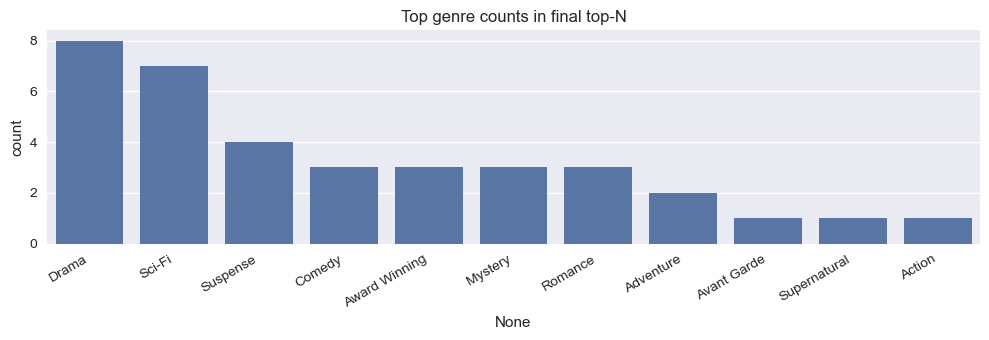

In [16]:
def genres_for_row(val) -> set[str]:
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return set()
    if isinstance(val, str):
        return {g.strip() for g in val.split('|') if g.strip()}
    if hasattr(val, '__iter__'):
        return {str(g).strip() for g in val if g}
    return set()


def genre_counts(df: pd.DataFrame) -> pd.Series:
    all_genres = []
    for g in df.get('genres', []):
        all_genres.extend(sorted(genres_for_row(g)))
    if not all_genres:
        return pd.Series(dtype=int)
    return pd.Series(all_genres).value_counts()


if ranked.empty:
    pass
else:
    gc = genre_counts(joined)
    if len(gc) == 0:
        print('No genre data available.')
    else:
        plt.figure(figsize=(10, 3.5))
        sns.barplot(x=gc.index[:12], y=gc.values[:12])
        plt.title('Top genre counts in final top-N')
        plt.ylabel('count')
        plt.xticks(rotation=30, ha='right')
        plt.tight_layout()
        plt.show()

## 8) Embedding Space (Optional)

If the neural synopsis embeddings artifact is present, we project a sample to 2D and visualize coarse genre clusters.

To keep runtime low, we sample and use PCA → t-SNE.

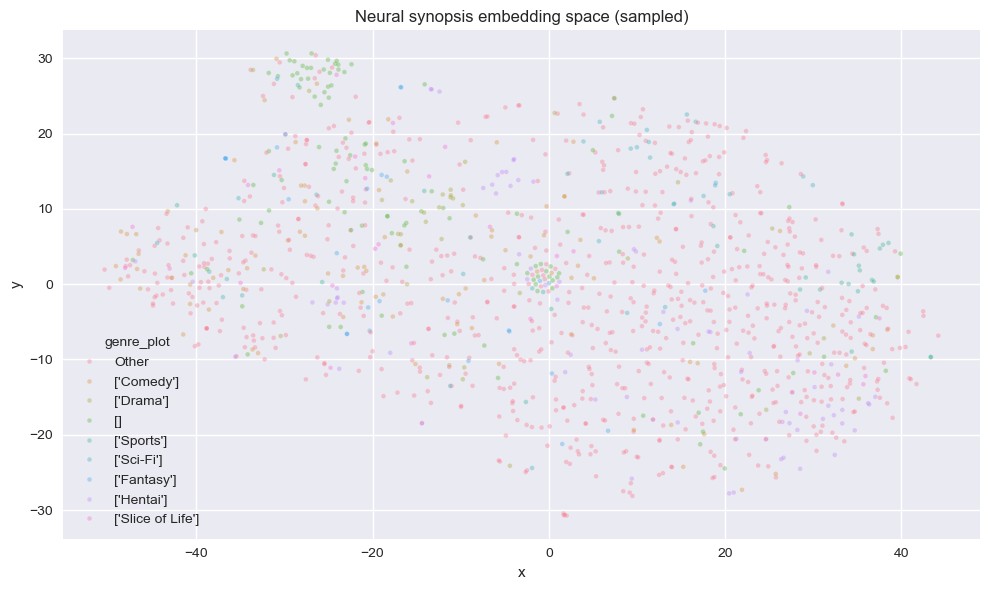

In [17]:
try:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
except Exception as e:
    PCA = None
    TSNE = None
    print(f'scikit-learn not available for embedding plot: {e}')

neural_artifact = bundle.get('models', {}).get('synopsis_neural_embeddings')
if PCA is None or TSNE is None or neural_artifact is None:
    print('Skipping embedding-space plot.')
else:
    anime_ids = np.asarray(getattr(neural_artifact, 'anime_ids'))
    X = np.asarray(getattr(neural_artifact, 'embeddings'))

    n = min(1200, len(anime_ids))
    rng = np.random.default_rng(42)
    idx = rng.choice(len(anime_ids), size=n, replace=False)
    ids_sample = anime_ids[idx].astype(int)
    Xs = X[idx]

    md_sample = metadata.loc[metadata['anime_id'].astype(int).isin(ids_sample), ['anime_id', 'genres']].copy()
    md_sample['anime_id'] = md_sample['anime_id'].astype(int)
    md_sample['primary_genre'] = md_sample['genres'].fillna('').astype(str).str.split('|').str[0].fillna('Other')

    X50 = PCA(n_components=min(50, Xs.shape[1]), random_state=42).fit_transform(Xs)
    X2 = TSNE(n_components=2, init='pca', learning_rate='auto', perplexity=35, random_state=42).fit_transform(X50)

    emb = pd.DataFrame({'x': X2[:, 0], 'y': X2[:, 1], 'anime_id': ids_sample})
    emb = emb.merge(md_sample[['anime_id', 'primary_genre']], on='anime_id', how='left')

    seed_mask = emb['anime_id'] == int(seed_id)
    rec_ids = set(ranked['anime_id'].astype(int).tolist()) if not ranked.empty else set()
    rec_mask = emb['anime_id'].isin(rec_ids)

    top_genres = emb['primary_genre'].value_counts().index[:8]
    emb['genre_plot'] = np.where(emb['primary_genre'].isin(top_genres), emb['primary_genre'], 'Other')

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=emb, x='x', y='y', hue='genre_plot', alpha=0.35, s=12, legend=True)
    if seed_mask.any():
        plt.scatter(emb.loc[seed_mask, 'x'], emb.loc[seed_mask, 'y'], s=140, c='black', marker='*', label='seed')
    if rec_mask.any():
        plt.scatter(emb.loc[rec_mask, 'x'], emb.loc[rec_mask, 'y'], s=70, c='white', edgecolors='black', linewidths=0.6, marker='o', label='recs')
    plt.title('Neural synopsis embedding space (sampled)')
    plt.tight_layout()
    plt.show()

## 9) Quick Ablation (Lightweight)

A full offline ablation is already captured in Phase 4 reports. Here we do a lightweight, qualitative ablation by changing the hybrid weights and inspecting top-10 ranking differences.

This answers the portfolio question: *What signal actually drives your ranking?*

In [18]:
from src.app.constants import DIVERSITY_EMPHASIZED_WEIGHTS


def run_with_weights(name: str, weights: dict[str, float]) -> pd.DataFrame:
    ctx2 = ScoringContext(
        metadata=metadata,
        bundle=bundle,
        recommender=recommender,
        components=components,
        seed_ids=[seed_id],
        seed_titles=[seed_title],
        user_index=0,
        weights=weights,
        n_requested=10,
        pop_pct_fn=pop_pct_fn,
    )
    res = run_seed_based_pipeline(ctx2)
    df = pd.DataFrame(res.ranked_items)
    if not df.empty:
        df['rank'] = np.arange(1, len(df) + 1)
        df['anime_id'] = df['anime_id'].astype(int)
    df['variant'] = name
    return df


ab = pd.concat(
    [run_with_weights('balanced', BALANCED_WEIGHTS), run_with_weights('diversity_emph', DIVERSITY_EMPHASIZED_WEIGHTS)],
    ignore_index=True,
)

cols = [c for c in ['anime_id', 'title_display', 'genres', 'type', 'mal_score'] if c in metadata.columns]
meta_small = metadata[cols].copy() if cols else metadata[['anime_id']].copy()
ab_joined = ab.merge(meta_small, on='anime_id', how='left')

display(ab_joined.sort_values(['variant', 'rank']).groupby('variant').head(10)[['variant', 'rank', 'anime_id', 'title_display', 'score', 'genres']])

overlap = set(ab_joined.loc[ab_joined['variant'] == 'balanced', 'anime_id']) & set(ab_joined.loc[ab_joined['variant'] == 'diversity_emph', 'anime_id'])
print('\nTop-10 overlap:')
print(sorted(overlap))

,variant,rank,anime_id,title_display,score,genres
0,balanced,1,32188,Steins;Gate: Open the Missing Link - Divide By Zero,2.977356,"[Sci-Fi, Suspense]"
1,balanced,2,30484,Steins;Gate 0,2.930731,"[Drama, Sci-Fi, Suspense]"
2,balanced,3,27957,Steins;Gate: The Sagacious Wisdom of Cognitive Computing,2.451917,"[Comedy, Sci-Fi]"
3,balanced,4,339,Serial Experiments Lain,1.921313,"[Avant Garde, Award Winning, Drama, Mystery, Sci-Fi, Supernatural, Suspense]"
4,balanced,5,329,Planetes,1.909734,"[Award Winning, Drama, Romance, Sci-Fi]"
5,balanced,6,18195,Little Busters! ~Refrain~,1.862852,"[Comedy, Drama, Romance]"
6,balanced,7,2164,Den-noh Coil,1.856780,"[Adventure, Award Winning, Drama, Mystery, Sci-Fi]"
7,balanced,8,19,Monster,1.817428,"[Drama, Mystery, Suspense]"
8,balanced,9,16,Honey and Clover,1.785290,"[Comedy, Drama, Romance]"
9,balanced,10,2747,Astro Boy,1.773233,"[Action, Adventure, Drama, Sci-Fi]"



Top-10 overlap:
[16, 19, 329, 339, 2164, 2747, 18195, 27957, 30484, 32188]


## Summary

This notebook demonstrated:
- Real artifact loading via `build_artifacts()`
- Stage 0 candidate generation breakdown (tiers + overlaps)
- End-to-end ranked pipeline execution via `run_seed_based_pipeline()`
- Readable Stage 2 outputs (scores, explanations, raw components)
- Optional embedding-space visualization (sampled)
- Lightweight ablation via weight variants

If you want, we can extend this to show pre/post-MMR diversity once you decide how you want to present λ in the portfolio narrative.